# Strong Scaling

This third experiment focus on the strong scaling.\
We fix $N$, vary $P$. Sample sort has $O(NlogN/P)$ local work and $O(N)$ aggregate communication; communication will dominate eventually. Find the cross-over for your machine.

The experiment focus mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 4. The number of **MPI ranks** increase exponentially from **4** to **64**.

* **n_bits** : $64$
* **n_keys** : $10^9$
* **n_threads** : $4$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metric here is **total_seconds**.

In [4]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [7]:
results = pd.read_csv("../Parallel/results/strong_scaling.csv")
results = results[
    ["n_bits", "n_key", "n_ranks", "n_threads", "time_total_seconds"]
]
results.head()

,n_bits,n_key,n_ranks,n_threads,time_total_seconds
0,64,1000000000,4,4,26.852991
1,64,1000000000,8,4,15.521991
2,64,1000000000,16,4,9.008321
3,64,1000000000,32,4,5.859905
4,64,1000000000,64,4,3.439271


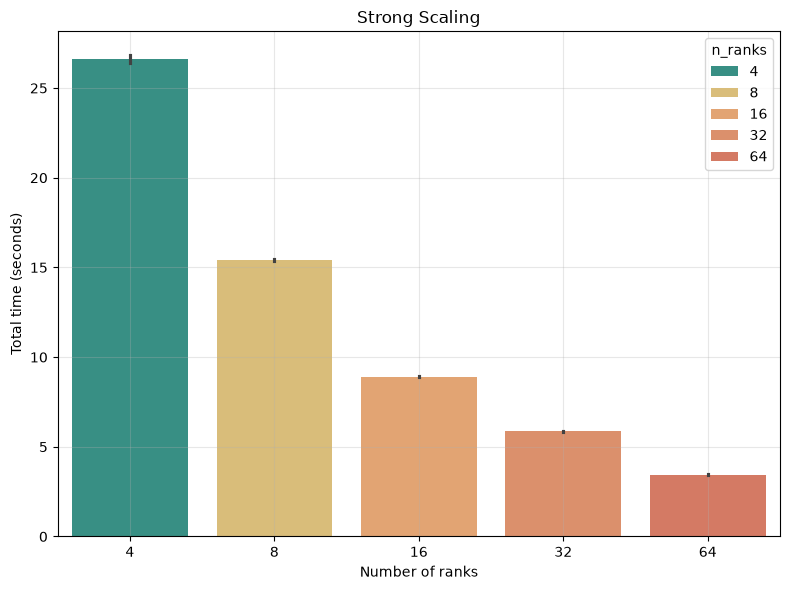

In [9]:
custom_palette = {
    1 :"#264653",
    2 : "#287271",
    4 : "#2a9d8f",
    8 : "#e9c46a",
    16 : "#f4a261",
    32 : "#ee8959",
    64 : "#e76f51"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_total_seconds",
    hue="n_ranks",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Total time (seconds)")
plt.title("Strong Scaling")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()